In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [29]:
dataset = pd.read_csv('E_Commerce_Dataset.csv')

In [30]:
dataset.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [31]:
dataset.shape

(5630, 20)

In [32]:
dataset.describe(include='all')

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630,5630.000000,5379.000000,5630,5630,5375.000000,5630.000000,5630,5630.000000,5630,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
unique,NaN,NaN,NaN,3,NaN,NaN,7,2,NaN,NaN,6,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Mobile Phone,NaN,NaN,Debit Card,Male,NaN,NaN,Laptop & Accessory,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2765,NaN,NaN,2314,3384,NaN,NaN,2050,NaN,2986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,52815.500000,0.168384,10.189899,NaN,1.654707,15.639896,NaN,NaN,2.931535,3.688988,NaN,3.066785,NaN,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,NaN,0.915389,8.531475,NaN,NaN,0.721926,1.023999,NaN,1.380194,NaN,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,NaN,1.000000,5.000000,NaN,NaN,0.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,NaN,1.000000,9.000000,NaN,NaN,2.000000,3.000000,NaN,2.000000,NaN,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,NaN,1.000000,14.000000,NaN,NaN,3.000000,4.000000,NaN,3.000000,NaN,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,NaN,3.000000,20.000000,NaN,NaN,3.000000,4.000000,NaN,4.000000,NaN,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000


In [33]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [34]:
dataset.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [35]:
num_cols_with_na = [
    'WarehouseToHome',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder',
    'Tenure',
    'HourSpendOnApp'
]

dataset[num_cols_with_na] = dataset[num_cols_with_na].fillna(
    dataset[num_cols_with_na].median()
)

# Confirm no missing values
print(dataset.isnull().sum())


CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64


In [36]:
dataset = dataset.dropna()

In [37]:
dataset.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

Splitting labels and features

In [38]:
X = dataset.iloc[:,2:].values
y = dataset.iloc[:,1].values

In [39]:
print(X)

[[4.0 'Mobile Phone' 3 ... 1.0 5.0 160]
 [9.0 'Phone' 1 ... 1.0 0.0 121]
 [9.0 'Phone' 1 ... 1.0 3.0 120]
 ...
 [1.0 'Mobile Phone' 1 ... 2.0 4.0 186]
 [23.0 'Computer' 3 ... 2.0 9.0 179]
 [8.0 'Mobile Phone' 1 ... 2.0 3.0 169]]


In [40]:
print(y)

[1 1 1 ... 0 0 0]


In [41]:
dataset.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [42]:
dataset.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object

In [43]:
columns_heads = dataset.columns.tolist()

In [44]:
i = 0
for j in columns_heads:
    if dataset[j].dtype == object:
        print(i-2,end='')
        print('\t' , columns_heads[i], end = '')
        print('\t\t' , dataset[j].dtype)
    i = i + 1

1	 PreferredLoginDevice		 object
4	 PreferredPaymentMode		 object
5	 Gender		 object
8	 PreferedOrderCat		 object
10	 MaritalStatus		 object


<!-- Encoding categorical data -->

## Splitting the dataset into the Training set and Test set

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# Encoding Categorical data

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1,4,5,8,10])], remainder='passthrough')
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

## Feature Scaling

In [47]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [48]:
print(X_train)

[[-0.64042487  1.02063923 -0.5300954  ... -0.67856791 -0.68590581
  -0.46422926]
 [-0.64042487  1.02063923 -0.5300954  ...  1.43625382  0.99292025
   0.55941149]
 [-0.64042487  1.02063923 -0.5300954  ...  0.02637267 -0.40610146
  -0.54612052]
 ...
 [ 1.5614634  -0.97977813 -0.5300954  ... -0.67856791 -0.68590581
  -0.40281082]
 [ 1.5614634  -0.97977813 -0.5300954  ... -0.67856791 -1.24551449
  -1.07841371]
 [-0.64042487  1.02063923 -0.5300954  ... -0.67856791 -0.68590581
  -0.46422926]]


# Training the Random Forest Classification model on the Training set

In [49]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 1000, class_weight='balanced',criterion='entropy', random_state=0)
classifier.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       n_estimators=1000, random_state=0)

# Predicting the Test set results

In [50]:
y_pred = classifier.predict(X_test)

print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_pred),1)),1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [1 1]
 [0 0]]


# Making the Confusion Matrix

In [51]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

print(classification_report(y_test, y_pred))

y_proba = classifier.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[936   3]
 [ 40 147]]
Accuracy: 0.9618117229129662
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       939
           1       0.98      0.79      0.87       187

    accuracy                           0.96      1126
   macro avg       0.97      0.89      0.92      1126
weighted avg       0.96      0.96      0.96      1126

AUC: 0.9864003690352121


Finding the Importance of Features

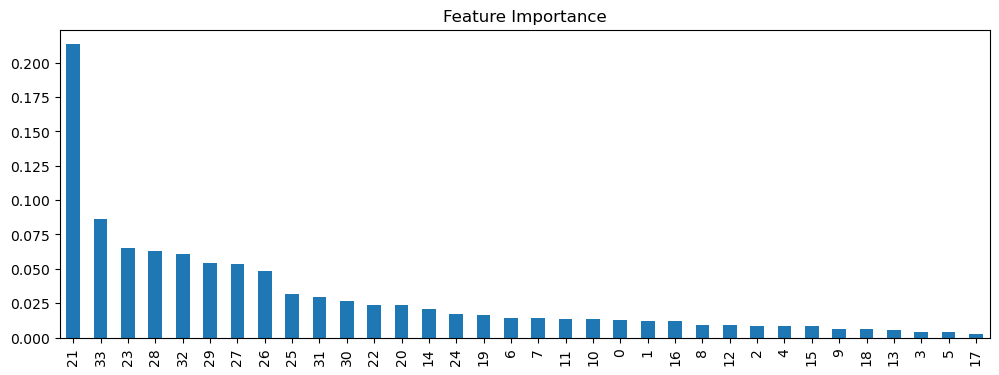

In [52]:
import pandas as pd

importances = pd.Series(classifier.feature_importances_)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,4), title='Feature Importance')
plt.show()


Downloading Random Forest model in pkl 

In [53]:
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/rf_model.pkl", "wb") as f:
    pickle.dump(classifier, f)

print("Saved Randomforest model as rf_model.pkl")


Saved Randomforest model as rf_model.pkl


Generating a final churn prediction CSV

In [54]:
output_df = pd.DataFrame({
    'Predicted': y_pred,
    'Actual': y_test,
    'Probability': y_proba
})
output_df.to_csv('final_churn_prediction_rf.csv', index=False)
print("Saved prediction CSV file as final_churn_prediction_rf.csv")


Saved prediction CSV file as final_churn_prediction_rf.csv
